In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

In [4]:
df = pd.read_csv("../data/robot_states_square.csv")
print(df.columns)

Index(['run_index', 'timestep', 'true_x', 'true_y', 'true_theta', 'control_x',
       'control_y', 'control_theta', 'lidar_readings'],
      dtype='object')


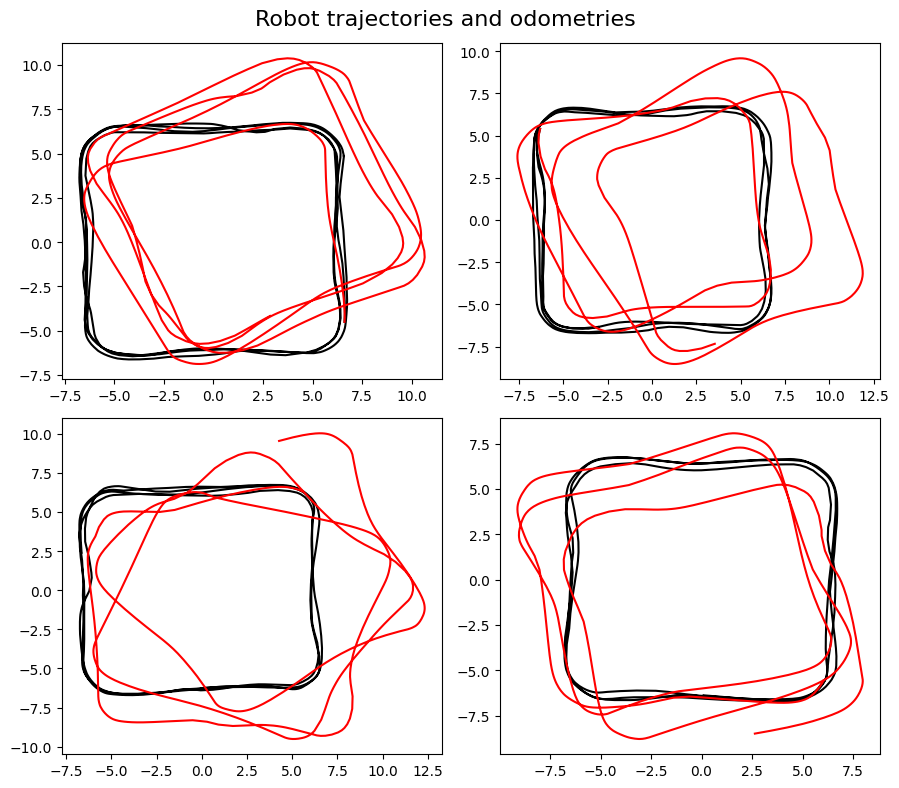

In [46]:

fig, axs = plt.subplots(2, 2, figsize=(9, 8))

axs = axs.flatten()

plt.suptitle("Robot trajectories and odometries", fontsize=16)

for i, ax in enumerate(axs):
    traj = df[df["run_index"] == i]
    ax.plot(traj.true_x, traj.true_y, "k-", label=f"GT")

    # Iterate over controls and move based on the odometry
    xs = [traj.true_x.to_numpy()[0]]
    ys = [traj.true_y.to_numpy()[0]]
    thetas = [traj.true_theta.to_numpy()[0]]

    control_xs = traj.control_x.to_numpy()
    control_ys = traj.control_y.to_numpy()
    control_as = traj.control_theta.to_numpy()

    for dx, dy, da in zip(control_xs, control_ys, control_as):
        x  = xs[-1]
        y  = ys[-1]
        a  = thetas[-1]

        x += dx * np.cos(a) - dy * np.sin(a)
        y += dx * np.sin(a) + dy * np.cos(a)
        a += da

        xs.append(x)
        ys.append(y)
        thetas.append(a)

    ax.plot(xs, ys, "r-", markersize=1)

plt.tight_layout()


    



[1.4920459  1.0288247  0.96871626 0.36725512 0.4458451  0.53901756
 0.6746616  1.5512192  2.0722294  2.1554697  1.5821182  1.1094338
 0.78014326 1.0358635  2.0821383  2.214885  ]
[2.0178883  1.046105   0.8154744  0.72473574 0.68134254 0.5117927
 0.6464403  1.1378391  2.01277    1.9449708  1.9494717  0.50409037
 0.69324464 1.3152101  1.9101651  2.0658762 ]
[2.0115027  2.0052297  1.7072955  1.3010023  1.120514   1.123111
 1.2568659  2.0359418  2.0086796  1.9790385  0.870026   0.38362554
 0.59350735 0.4889189  0.50273633 1.6308001 ]
[1.7476596  1.034106   0.77396697 0.6308394  0.5044137  0.5937065
 0.6615674  1.0387194  1.8424119  1.9528192  1.9051418  1.1760932
 0.88199013 1.6689755  1.8788785  2.0504565 ]


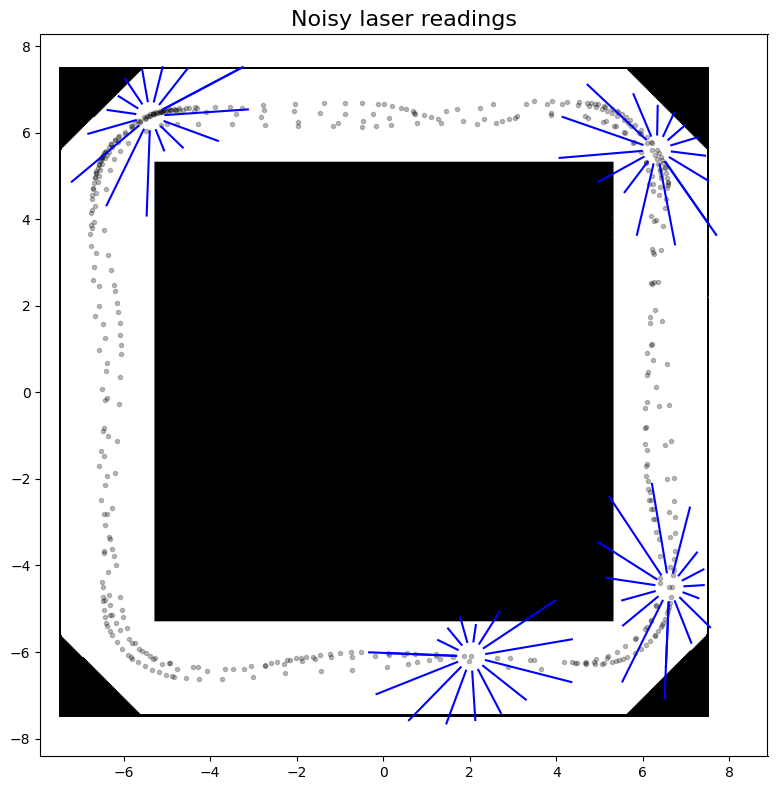

In [44]:
# Visualize laser readings
traj = df[df["run_index"] == 0]
robot_radius = 0.35

plt.figure(figsize=(8, 8))
plt.title("Noisy laser readings", fontsize=16)
plt.tight_layout()
plt.axis("equal")

plt.plot(traj.true_x, traj.true_y, "k.", label=f"GT", alpha=0.25)

# Show image
img = plt.imread("../images/square.png")
plt.imshow(img, cmap="gray", extent=[-7.5, 7.5, -7.5, 7.5], zorder=-1)

# Visualize only first few
laser_ix = np.arange(0, 200, 60)
for i in laser_ix:
    x = traj.true_x.to_numpy()[i]
    y = traj.true_y.to_numpy()[i]
    a = traj.true_theta.to_numpy()[i]

    
    readings = np.fromstring(traj.lidar_readings.to_numpy()[i], sep=",")
    theta_offset = np.linspace(-np.pi, np.pi, len(readings))
    for r, t in zip(readings, theta_offset):
           # Add robot radius to start coords
            x_start = x + robot_radius * np.cos(a + t)
            y_start = y + robot_radius * np.sin(a + t)

            x_end = x + (r + robot_radius) * np.cos(a + t)
            y_end = y + (r + robot_radius) * np.sin(a + t)
            plt.plot([x_start, x_end], [y_start, y_end], "b-")
    print(readings)

